# Product Name TF-IDF by Category (검증)

제품명을 **카테고리별**로 묶어 TF-IDF를 적용하고, 일반어(티, 가방 등)가 걸러지는지 워드클라우드로 검증합니다.

In [45]:
# 필요시 1회 설치
# %pip install scikit-learn pandas matplotlib wordcloud

from __future__ import annotations

import sys
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import wordcloud_lab as wl

In [46]:
RUNS_DIR = PROJECT_ROOT / "runs"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "product_name_category_tfidf"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_DIR: Path | None = None  # 특정 run 지정 시 Path("...")

# 카테고리 내부 TF-IDF 하이퍼파라미터
TOP_K = 40
NGRAM_RANGE = (1, 2)
MIN_PRODUCTS_PER_CATEGORY = 50
MIN_DF_RATIO = 0.005
MAX_DF_RATIO = 0.10
USE_SUBLINEAR_TF = True

run_dir = wl.resolve_run_dir(RUNS_DIR, RUN_DIR)
items = wl.load_items(run_dir)
product_only = wl.product_items(items)

font_path, _ = wl.init_fonts()
if font_path:
    print(f"font: {font_path}")
print(f"run_dir={run_dir}")
print(f"items={len(items):,}, product_only={len(product_only):,}")

font: /System/Library/Fonts/Supplemental/AppleGothic.ttf
run_dir=/Users/bhc/dev/datadrift/v1/datadrift_app_engine/v2/silhouette_outliner/runs/20260527_172433
items=13,747, product_only=12,000


In [47]:
def build_product_docs(items: list[dict]) -> pd.DataFrame:
    """상품 1개를 문서 1개로 만든다 (카테고리 내부 TF-IDF용)."""
    ubiquitous = wl.ubiquitous_for_items(items)
    rows: list[dict] = []

    for it in wl.product_items(items):
        code, label = wl.category_key(it)
        if code in wl.SKIP_CATEGORY_CODES:
            continue
        name = wl.product_display_name(it)
        if not name:
            continue

        stop = wl.generic_stopwords_for(code, label, ubiquitous)
        toks = [t for t in wl.tokenize_product_name(name) if t not in stop]
        if not toks:
            continue

        rows.append(
            {
                "category_code": code,
                "category_label": label,
                "tokens": toks,
                "doc": " ".join(toks),
            }
        )

    return pd.DataFrame(rows)


product_docs_df = build_product_docs(items)
if product_docs_df.empty:
    raise ValueError("문서가 비어 있습니다. 전처리/입력 데이터를 확인하세요.")

category_stats_df = (
    product_docs_df.groupby(["category_code", "category_label"], as_index=False)
    .agg(product_docs=("doc", "count"), token_count=("tokens", lambda s: int(sum(len(x) for x in s))))
    .sort_values("category_code")
)
category_stats_df

,category_code,category_label,product_docs,token_count
0,001000,상의,2905,9729
1,002000,아우터,2991,11682
2,003000,바지,2977,11967
3,004000,가방,2938,8116


In [48]:
def run_tfidf_per_category(product_docs_df: pd.DataFrame) -> pd.DataFrame:
    records: list[dict] = []
    for (code, label), group in product_docs_df.groupby(["category_code", "category_label"], sort=True):
        n_docs = len(group)
        if n_docs < MIN_PRODUCTS_PER_CATEGORY:
            continue

        min_df = max(1, int(np.ceil(n_docs * MIN_DF_RATIO)))
        vectorizer = TfidfVectorizer(
            tokenizer=str.split,
            preprocessor=None,
            token_pattern=None,
            lowercase=False,
            ngram_range=NGRAM_RANGE,
            min_df=min_df,
            max_df=MAX_DF_RATIO,
            sublinear_tf=USE_SUBLINEAR_TF,
        )
        X = vectorizer.fit_transform(group["doc"].tolist())
        terms = np.array(vectorizer.get_feature_names_out())

        tfidf_sum = np.asarray(X.sum(axis=0)).ravel()
        df_ratio = np.asarray((X > 0).sum(axis=0)).ravel() / n_docs

        order = np.argsort(tfidf_sum)[::-1][:TOP_K]
        for rank, j in enumerate(order, start=1):
            records.append(
                {
                    "category_code": code,
                    "category_label": label,
                    "n_docs": n_docs,
                    "rank": rank,
                    "term": terms[j],
                    "tfidf": float(tfidf_sum[j]),
                    "doc_freq_ratio": float(df_ratio[j]),
                }
            )

    return pd.DataFrame(records)


top_terms_df = run_tfidf_per_category(product_docs_df)
if top_terms_df.empty:
    raise ValueError("TF-IDF 결과가 비었습니다. MIN_PRODUCTS_PER_CATEGORY / MAX_DF_RATIO 등을 낮춰 보세요.")

top_terms_df.head(30)

,category_code,category_label,n_docs,rank,term,tfidf,doc_freq_ratio
0,001000,상의,2905,1,니트,90.096511,0.093976
1,001000,상의,2905,2,헨리넥,89.856135,0.091566
2,001000,상의,2905,3,폴로,86.110569,0.075387
3,001000,상의,2905,4,logo,85.072035,0.039587
4,001000,상의,2905,5,피그먼트,75.995100,0.046472
5,001000,상의,2905,6,스트라이프,70.800159,0.049570
6,001000,상의,2905,7,half,60.440057,0.033046
7,001000,상의,2905,8,오버핏,59.178830,0.059208
8,001000,상의,2905,9,링거,58.455662,0.039587
9,001000,상의,2905,10,반팔티,56.217755,0.045439


In [49]:
top_terms_df.head(30)

,category_code,category_label,n_docs,rank,term,tfidf,doc_freq_ratio
0,001000,상의,2905,1,니트,90.096511,0.093976
1,001000,상의,2905,2,헨리넥,89.856135,0.091566
2,001000,상의,2905,3,폴로,86.110569,0.075387
3,001000,상의,2905,4,logo,85.072035,0.039587
4,001000,상의,2905,5,피그먼트,75.995100,0.046472
5,001000,상의,2905,6,스트라이프,70.800159,0.049570
6,001000,상의,2905,7,half,60.440057,0.033046
7,001000,상의,2905,8,오버핏,59.178830,0.059208
8,001000,상의,2905,9,링거,58.455662,0.039587
9,001000,상의,2905,10,반팔티,56.217755,0.045439


## 워드클라우드 (카테고리별 필터링 검증)

각 카테고리마다 **원본 빈도** vs **TF-IDF 상위 용어×원본 빈도**를 나란히 비교합니다.
글자 크기 = 해당 카테고리 문서 내 토큰 빈도. 일반어(티, 가방 등)는 오른쪽에서 사라져야 합니다.

In [50]:
def count_term_in_tokens(term: str, tokens: list[str]) -> int:
    parts = term.split()
    n = len(parts)
    if n == 1:
        return tokens.count(term)
    return sum(1 for i in range(len(tokens) - n + 1) if tokens[i : i + n] == parts)


def count_term_in_docs(term: str, docs_tokens: list[list[str]]) -> int:
    return sum(count_term_in_tokens(term, toks) for toks in docs_tokens)


def counter_from_terms(terms: list[str], docs_tokens: list[list[str]]) -> Counter:
    ctr: Counter = Counter()
    for term in terms:
        c = count_term_in_docs(term, docs_tokens)
        if c > 0:
            ctr[term] = c
    return ctr


raw_by_cat: dict[tuple[str, str], Counter] = {}
for (code, label), group in product_docs_df.groupby(["category_code", "category_label"], sort=True):
    raw_by_cat[(code, label)] = Counter(tok for toks in group["tokens"] for tok in toks)

filtered_by_cat: dict[tuple[str, str], Counter] = {}
freq_rows: list[dict] = []
for (code, label), group in top_terms_df.groupby(["category_code", "category_label"], sort=True):
    docs_tokens = product_docs_df.loc[
        (product_docs_df["category_code"] == code) & (product_docs_df["category_label"] == label),
        "tokens",
    ].tolist()
    terms = group["term"].tolist()
    ctr = counter_from_terms(terms, docs_tokens)
    filtered_by_cat[(code, label)] = ctr

    for _, row in group.iterrows():
        freq_rows.append({**row.to_dict(), "count": ctr.get(row["term"], 0)})

top_terms_with_freq = pd.DataFrame(freq_rows)
print("카테고리:", {code: label for code, label in raw_by_cat.keys()})

카테고리: {'001000': '상의', '002000': '아우터', '003000': '바지', '004000': '가방'}


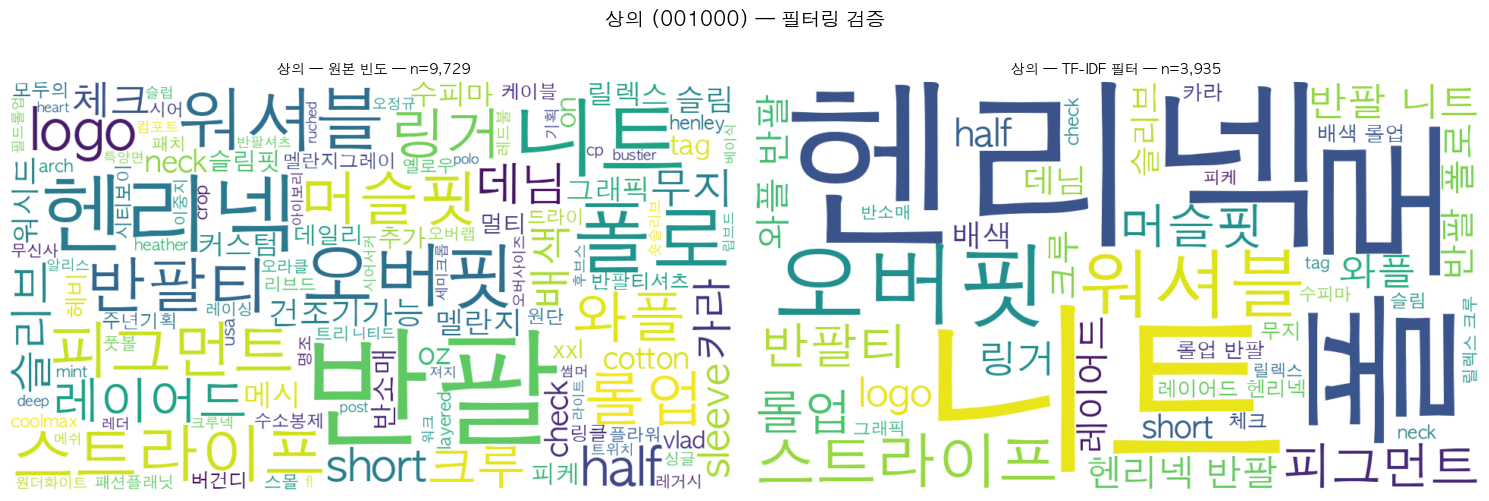

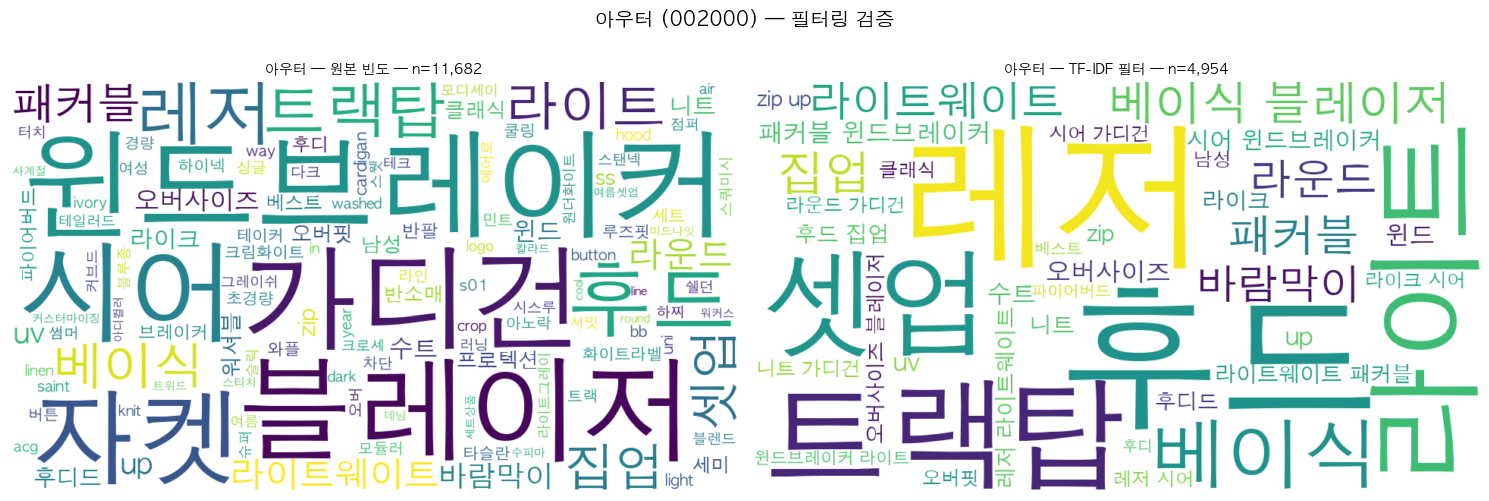

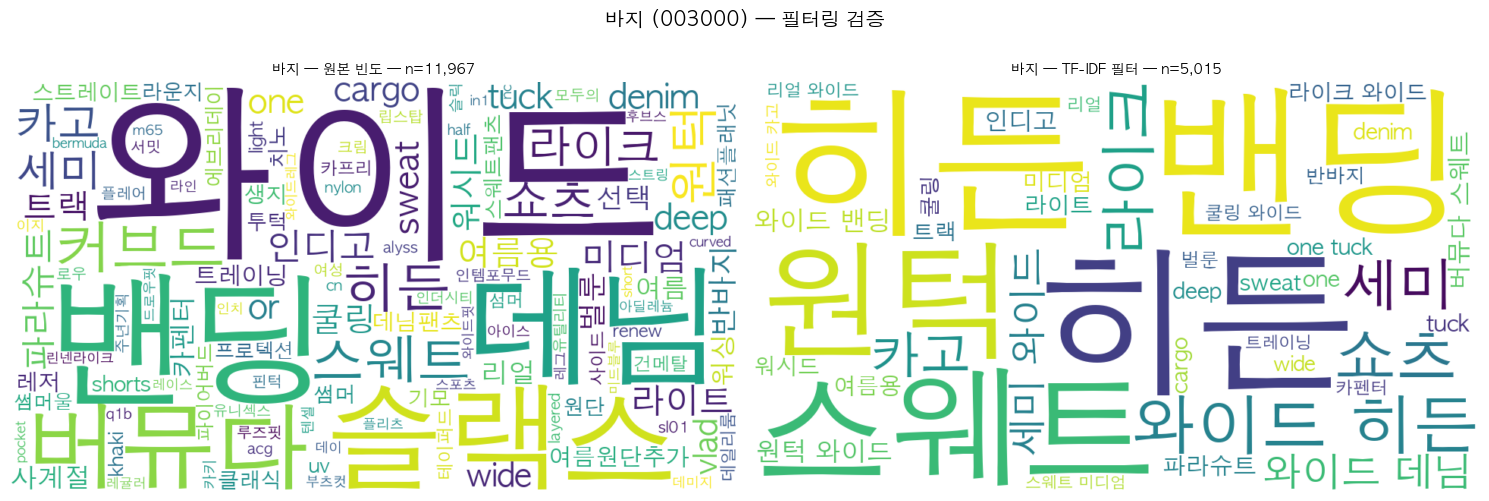

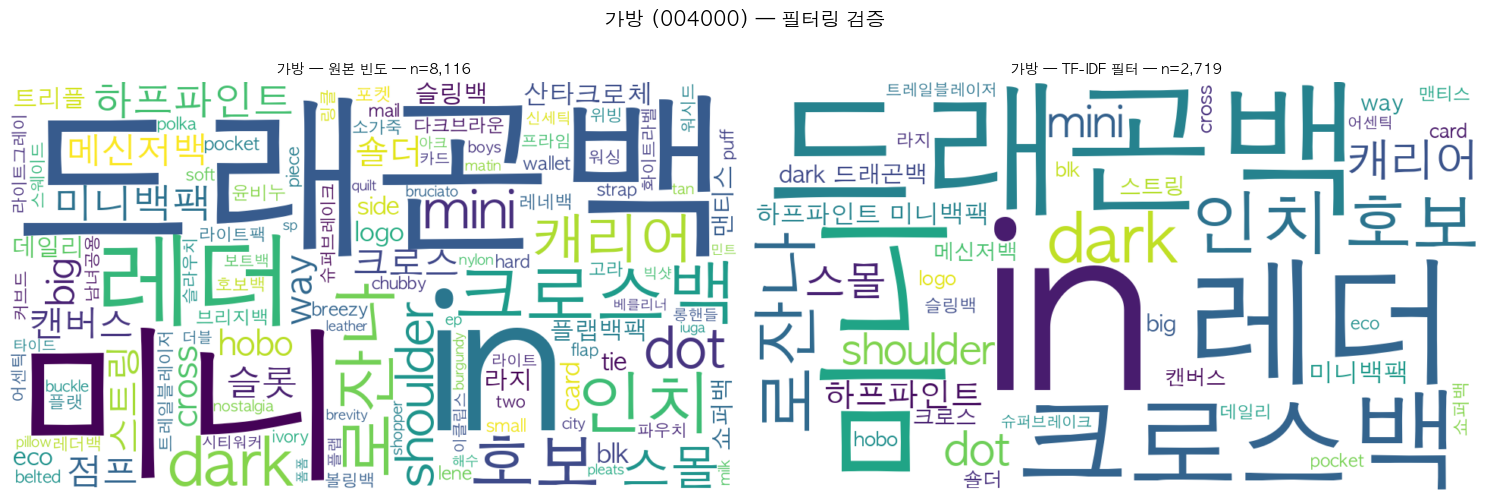

In [51]:
# 카테고리별 필터링 전/후 비교 (빈도 = 원본 토큰 수)
run_name = run_dir.name

for (code, label) in sorted(raw_by_cat.keys()):
    ctr_r = raw_by_cat[(code, label)]
    ctr_f = filtered_by_cat.get((code, label), Counter())
    wl.plot_wordcloud_grid(
        [
            (f"{label} — 원본 빈도", ctr_r),
            (f"{label} — TF-IDF 필터", ctr_f),
        ],
        suptitle=f"{label} ({code}) — 필터링 검증",
        ncols=2,
        figsize_per_cell=(7.5, 5.0),
        save_path=OUTPUT_DIR / f"{run_name}_{code}_raw_vs_tfidf_wordcloud.png",
    )

In [52]:
# 카테고리별 상위 TF-IDF 용어 (빈도/문서출현비율 포함)
for (code, label), group in top_terms_with_freq.groupby(["category_code", "category_label"], sort=True):
    print(f"\n=== {label} ({code}) ===")
    display(group[["rank", "term", "count", "doc_freq_ratio", "tfidf"]].head(TOP_K))


=== 상의 (001000) ===


,rank,term,count,doc_freq_ratio,tfidf
0,1,니트,273,0.093976,90.096511
1,2,헨리넥,266,0.091566,89.856135
2,3,폴로,219,0.075387,86.110569
3,4,logo,115,0.039587,85.072035
4,5,피그먼트,137,0.046472,75.995100
5,6,스트라이프,144,0.049570,70.800159
6,7,half,96,0.033046,60.440057
7,8,오버핏,172,0.059208,59.178830
8,9,링거,115,0.039587,58.455662
9,10,반팔티,132,0.045439,56.217755



=== 아우터 (002000) ===


,rank,term,count,doc_freq_ratio,tfidf
40,1,베이식,175,0.058509,116.654141
41,2,베이식 블레이저,172,0.057506,116.217781
42,3,레저,234,0.078235,91.356057
43,4,후드,237,0.079238,90.561244
44,5,오버사이즈,131,0.043798,87.027070
45,6,트랙탑,191,0.063858,79.940254
46,7,라이트,189,0.063190,75.716880
47,8,오버사이즈 블레이저,103,0.034437,72.856081
48,9,집업,172,0.057506,72.537411
49,10,라이트웨이트,147,0.049147,62.656609



=== 바지 (003000) ===


,rank,term,count,doc_freq_ratio,tfidf
80,1,히든 밴딩,290,0.097414,119.368245
81,2,히든,290,0.097414,119.368245
82,3,스웨트,270,0.090695,117.994408
83,4,와이드 히든,232,0.077931,102.052908
84,5,쇼츠,206,0.069197,97.846439
85,6,원턱,253,0.084985,81.060382
86,7,세미,178,0.059792,76.107932
87,8,와이드 밴딩,142,0.047699,72.174613
88,9,버뮤다 스웨트,132,0.044340,70.601648
89,10,라이크,182,0.061135,69.923796



=== 가방 (004000) ===


,rank,term,count,doc_freq_ratio,tfidf
120,1,in,198,0.067393,109.791319
121,2,드래곤백,184,0.062628,78.082875
122,3,미니,163,0.055480,78.039209
123,4,레더,162,0.055140,72.250914
124,5,크로스백,107,0.036419,64.930046
125,6,캐리어,84,0.028251,50.451322
126,7,호보,91,0.030973,48.301350
127,8,shoulder,68,0.023145,47.874276
128,9,인치,100,0.025868,45.776260
129,10,로잔나,94,0.031995,45.187749


In [53]:
summary_df = (
    top_terms_with_freq.groupby(["category_code", "category_label"], as_index=False)
    .agg(
        top_term_count=("term", "count"),
        product_docs=("n_docs", "max"),
        max_tfidf=("tfidf", "max"),
        mean_tfidf=("tfidf", "mean"),
        mean_doc_freq_ratio=("doc_freq_ratio", "mean"),
    )
    .sort_values("category_code")
)
summary_df

,category_code,category_label,top_term_count,product_docs,max_tfidf,mean_tfidf,mean_doc_freq_ratio
0,001000,상의,40,2905,90.096511,45.260030,0.033847
1,002000,아우터,40,2991,116.654141,56.309195,0.041341
2,003000,바지,40,2977,119.368245,55.317709,0.042098
3,004000,가방,40,2938,109.791319,38.893092,0.022873


In [54]:
run_name = run_dir.name
out_csv = OUTPUT_DIR / f"{run_name}_category_productdoc_tfidf_top_terms.csv"
out_freq_csv = OUTPUT_DIR / f"{run_name}_category_productdoc_tfidf_top_terms_with_freq.csv"
out_summary_csv = OUTPUT_DIR / f"{run_name}_category_productdoc_tfidf_summary.csv"

top_terms_df.to_csv(out_csv, index=False, encoding="utf-8-sig")
top_terms_with_freq.to_csv(out_freq_csv, index=False, encoding="utf-8-sig")
summary_df.to_csv(out_summary_csv, index=False, encoding="utf-8-sig")

print("saved:", out_csv)
print("saved:", out_freq_csv)
print("saved:", out_summary_csv)

saved: /Users/bhc/dev/datadrift/v1/datadrift_app_engine/v2/silhouette_outliner/notebooks/output/product_name_category_tfidf/20260527_172433_category_productdoc_tfidf_top_terms.csv
saved: /Users/bhc/dev/datadrift/v1/datadrift_app_engine/v2/silhouette_outliner/notebooks/output/product_name_category_tfidf/20260527_172433_category_productdoc_tfidf_top_terms_with_freq.csv
saved: /Users/bhc/dev/datadrift/v1/datadrift_app_engine/v2/silhouette_outliner/notebooks/output/product_name_category_tfidf/20260527_172433_category_productdoc_tfidf_summary.csv


In [55]:
# 일반어 잔존 점검: 문서출현비율이 높은 단어가 상위권에 남는지 확인
GENERIC_CHECK = ("티", "가방", "티셔츠", "반팔", "팬츠", "신발", "백")
HIGH_DF_THRESHOLD = 0.20

check = top_terms_with_freq[
    (top_terms_with_freq["term"].isin(GENERIC_CHECK)) | (top_terms_with_freq["doc_freq_ratio"] >= HIGH_DF_THRESHOLD)
][["category_code", "category_label", "rank", "term", "count", "doc_freq_ratio", "tfidf"]]

if check.empty:
    print("상위 TF-IDF 목록에서 일반어/고문서빈도 단어가 크게 보이지 않습니다.")
else:
    print("점검 필요 단어(일반어 또는 높은 문서출현비율):")
    display(check.sort_values(["category_code", "rank"]))

상위 TF-IDF 목록에서 일반어/고문서빈도 단어가 크게 보이지 않습니다.
